
# Detailed Blockchain Lab Notebook with Visualizations
This notebook provides:
- Clear explanations for each concept
- A full blockchain implementation
- Proof-of-Work, difficulty, transactions, mining rewards
- Mining time visualization
---


**Note:
A real blockchain is a distributed system with multiple nodes, networks, consensus rules, and security mechanisms.
This notebook provides only a simplified, single‑node demonstration for learning purposes.**

##  Imports

In [1]:
import hashlib  # for SHA‑256 hashing
import json     # for JSON encoding
import time     # for timestamps and timing
import random   # for random test values
import matplotlib.pyplot as plt  # for plotting charts
from typing import List, Dict, Any  # for type hints

**Block Class**

A block contains transactions and must be mined by finding a valid hash starting with a number of leading zeros determined by the difficulty.

In [2]:

class Block:
    def __init__(self, index, timestamp, transactions, previous_hash, difficulty):
        self.index = index              # block number
        self.timestamp = timestamp      # time created
        self.transactions = transactions # list of txs
        self.previous_hash = previous_hash  # hash of previous block
        self.difficulty = difficulty    # mining difficulty
        self.nonce = 0                  # PoW counter
        self.hash = None                # final block hash

    def compute_hash(self):
        data = {
            "index": self.index,
            "timestamp": self.timestamp,
            "transactions": self.transactions,
            "previous_hash": self.previous_hash,
            "difficulty": self.difficulty,
            "nonce": self.nonce
        }
        return hashlib.sha256(json.dumps(data, sort_keys=True).encode()).hexdigest()  # compute hash

    def mine(self):
        target = '0' * self.difficulty  # target prefix
        start = time.time()             # start time
        attempts = 0                    # count tries
        while True:
            self.hash = self.compute_hash()  # calculate hash
            if self.hash.startswith(target):  # valid PoW?
                break
            self.nonce += 1                  # try next nonce
            attempts += 1
        return time.time() - start, attempts  # mining duration + attempts


##  Blockchain Class

The blockchain links blocks together and manages transactions, mining, verification, and exporting.

In [3]:

class Blockchain:
    def __init__(self, difficulty=3, reward=10):
        self.chain = []                # list of blocks
        self.difficulty = difficulty   # mining difficulty
        self.reward = reward           # block reward
        self.pending = []              # pending transactions
        self.create_genesis()          # create first block

    def create_genesis(self):
        b = Block(
            0,
            time.time(),
            [{"sender": "network", "recipient": "genesis", "amount": 0}],
            "0",
            self.difficulty
        )
        b.mine()                       # mine genesis block
        self.chain.append(b)           # add to chain

    def add_transaction(self, sender, recipient, amount):
        self.pending.append({
            "sender": sender,
            "recipient": recipient,
            "amount": amount
        })                             # store pending tx

    def mine_pending(self, miner):
        reward_tx = {"sender": "network", "recipient": miner, "amount": self.reward}
        txs = [reward_tx] + self.pending            # include reward + pending txs
        prev = self.chain[-1]                       # last block
        b = Block(len(self.chain), time.time(), txs, prev.hash, self.difficulty)
        t, attempts = b.mine()                      # mine new block
        self.chain.append(b)                        # add block to chain
        self.pending = []                           # clear mempool
        return t, attempts                          # return mining stats

    def export_json(self, filename):
        data = [b.__dict__ for b in self.chain]     # serialize blocks
        s = json.dumps(data, indent=2)              # format JSON
        open(filename, 'w').write(s)                # write file
        return s                                    # return JSON string


## 🚀 Example: Create Blockchain and Add Transactions

In [4]:

bc = Blockchain(difficulty=5, reward=25)   # create blockchain

# Add transactions
bc.add_transaction("Alice", "Bob", 10)      # Alice → Bob
bc.add_transaction("Bob", "Charlie", 5)     # Bob → Charlie
bc.add_transaction("Charlie", "Dave", 2)    # Charlie → Dave

time_taken, attempts = bc.mine_pending("Miner1")  # mine block + reward
print("Mining time:", time_taken, "seconds")       # show mining time
print("Attempts:", attempts)                       # show attempts made

Mining time: 35.25836181640625 seconds
Attempts: 1084261


In [5]:
for b in bc.chain:
    print(f"Block #{b.index}")
    print(f" Timestamp   : {b.timestamp}")
    print(f" Hash        : {b.hash}")
    print(f" Prev Hash   : {b.previous_hash}")
    print(f" Difficulty  : {b.difficulty}")
    print(f" Nonce       : {b.nonce}")
    print(f" Transactions: {b.transactions}")
    print("-" * 50)

Block #0
 Timestamp   : 1774269127.5124452
 Hash        : 0000056fcdd71ea39e24c0be9a94806b19d852810ed896f36163dc766cb91b7c
 Prev Hash   : 0
 Difficulty  : 5
 Nonce       : 70462
 Transactions: [{'sender': 'network', 'recipient': 'genesis', 'amount': 0}]
--------------------------------------------------
Block #1
 Timestamp   : 1774269129.3608596
 Hash        : 00000ffa235abb38e674cc16069d3cb95b261368b154ab482cdd7f31a51903dd
 Prev Hash   : 0000056fcdd71ea39e24c0be9a94806b19d852810ed896f36163dc766cb91b7c
 Difficulty  : 5
 Nonce       : 1084261
 Transactions: [{'sender': 'network', 'recipient': 'Miner1', 'amount': 25}, {'sender': 'Alice', 'recipient': 'Bob', 'amount': 10}, {'sender': 'Bob', 'recipient': 'Charlie', 'amount': 5}, {'sender': 'Charlie', 'recipient': 'Dave', 'amount': 2}]
--------------------------------------------------


## Mining Time Visualization

We test multiple difficulty levels and plot the mining times to show how difficulty impacts mining cost.

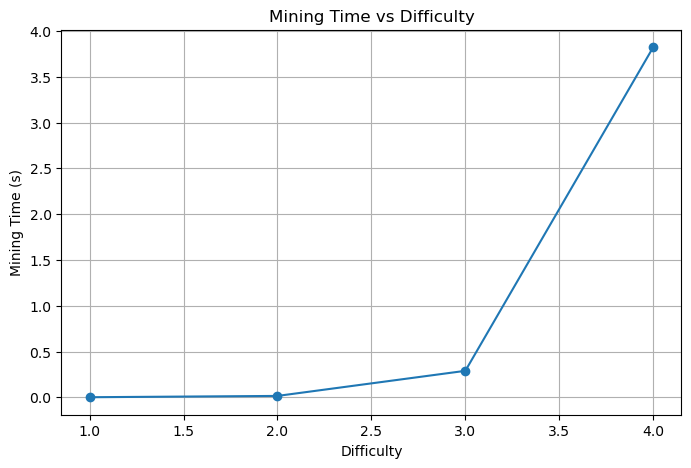

In [6]:

difficulties = [1, 2, 3, 4]        # test difficulty levels
times = []                         # store mining times

for d in difficulties:
    bc = Blockchain(difficulty=d, reward=1)  # new chain per difficulty
    bc.add_transaction("A", "B", 1)          # simple tx
    t, att = bc.mine_pending("MinerX")       # mine and time
    times.append(t)                           # record time

plt.figure(figsize=(8, 5))                   # set figure size
plt.plot(difficulties, times, marker='o')    # line plot with markers
plt.xlabel('Difficulty')                     # x-axis label
plt.ylabel('Mining Time (s)')                # y-axis label
plt.title('Mining Time vs Difficulty')       # chart title
plt.grid(True)                               # show grid
plt.show()                                   # render plot


#  Student Challenges
1. Note that your data is not encrypted inside the blocks, so anyone can read it. Encrypt the data before storing it in each block. Use encryption methods such as AES or 3DES.

2. Modify the mining function so it no longer uses leading‑zero matching; instead apply a different Proof‑of‑Work rule, such as a numeric hash threshold, pattern matching, or a time‑limited mining attempt.

Some options can be:

* Numeric threshold: Convert the hash to an integer and check if it's below a target value.
* Pattern rule: Make the hash end with certain characters (e.g., "00"), or require a substring inside the hash.
* Time‑limited PoW: Stop mining after a fixed time or attempt limit and mark the block as failed.
* Difficulty idea: Control difficulty by adjusting pattern length or the numeric target size.


# LAB-LOGBOOK requirement:
Show a graph comparing the mining time of the different Proof‑of‑Work methods used in Challenge 2.









Threshold PoW Time: 3.0992250442504883
Pattern PoW Time: 0.04873490333557129
Time-limited PoW Time: 0.0016429424285888672


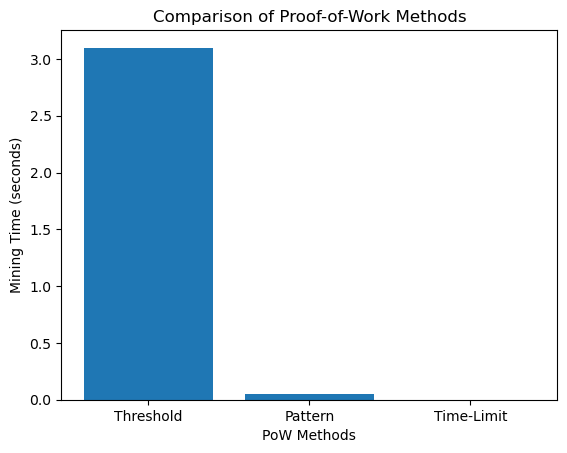

In [8]:
import hashlib
import time
import base64
import matplotlib.pyplot as plt
from Crypto.Cipher import AES
from Crypto.Random import get_random_bytes

# AES ENCRYPTION FUNCTIONS
def encrypt_data(data, key):
    cipher = AES.new(key, AES.MODE_EAX)
    ciphertext, tag = cipher.encrypt_and_digest(data.encode())
    return base64.b64encode(cipher.nonce + ciphertext).decode()

def decrypt_data(enc_data, key):
    raw = base64.b64decode(enc_data)
    nonce = raw[:16]
    ciphertext = raw[16:]
    cipher = AES.new(key, AES.MODE_EAX, nonce=nonce)
    return cipher.decrypt(ciphertext).decode()

# BLOCK CLASS
class Block:
    def __init__(self, data, key):
        self.key = key
        self.data = encrypt_data(data, key)
        self.nonce = 0
        self.hash = self.calculate_hash()

    def calculate_hash(self):
        block_string = str(self.data) + str(self.nonce)
        return hashlib.sha256(block_string.encode()).hexdigest()

    # 1. NUMERIC THRESHOLD PoW
    
    def mine_threshold(self, difficulty):
        target = 2 ** (256 - difficulty)
        start = time.time()

        while True:
            self.hash = self.calculate_hash()
            if int(self.hash, 16) < target:
                break
            self.nonce += 1

        return time.time() - start

    # 2. PATTERN MATCHING PoW
    def mine_pattern(self, pattern="00"):
        start = time.time()

        while True:
            self.hash = self.calculate_hash()
            if self.hash.endswith(pattern):
                break
            self.nonce += 1

        return time.time() - start

    # 3. TIME-LIMITED PoW
    
    def mine_time_limited(self, max_time=2):
        start = time.time()

        while time.time() - start < max_time:
            self.hash = self.calculate_hash()
            if self.hash.endswith("00"):
                return time.time() - start
            self.nonce += 1

        return max_time  # mining stopped

# TESTING & COMPARISON

if __name__ == "__main__":
    key = get_random_bytes(16)

    # Create blocks
    block1 = Block("Hello Blockchain", key)
    block2 = Block("Hello Blockchain", key)
    block3 = Block("Hello Blockchain", key)

    # Run different PoW methods
    time_threshold = block1.mine_threshold(difficulty=20)
    time_pattern = block2.mine_pattern(pattern="000")
    time_timelimit = block3.mine_time_limited(max_time=2)

    # Print results
    print("Threshold PoW Time:", time_threshold)
    print("Pattern PoW Time:", time_pattern)
    print("Time-limited PoW Time:", time_timelimit)

    # GRAPH
    
    methods = ["Threshold", "Pattern", "Time-Limit"]
    times = [time_threshold, time_pattern, time_timelimit]

    plt.bar(methods, times)
    plt.xlabel("PoW Methods")
    plt.ylabel("Mining Time (seconds)")
    plt.title("Comparison of Proof-of-Work Methods")
    plt.show()